EXPERIMENT 5
Dynamic Programming using Policy Iteration and Value Iteration

Aim:
To implement Dynamic Programming using
Policy Iteration and Value Iteration
and compare their performance.

Theory:
Dynamic Programming solves Markov Decision Processes (MDPs).
Two important algorithms are:
1. Policy Iteration
2. Value Iteration

Initial Policy
S0 -> Right
S1 -> Left
S2 -> Right
S3 -> Right
Goal -> Left

Policy Iteration Completed
Iterations : 2
Execution Time : 0.00075 seconds

Optimal Policy
S0 -> Right
S1 -> Right
S2 -> Right
S3 -> Right
Goal -> Left


VALUE ITERATION COMPLETED
Iterations : 6
Execution Time : 0.00052 seconds

Optimal Policy using Value Iteration
S0 ----> Move Right
S1 ----> Move Right
S2 ----> Move Right
S3 ----> Move Right
Goal ----> Terminal


FINAL STATE VALUES
S0 : 45.95
S1 : 51.05
S2 : 54.5
S3 : 55.0
Goal : 50.0


ALGORITHM COMPARISON
          Algorithm  Iterations  Execution Time
0  Policy Iteration           2         0.00075
1   Value Iteration           6    

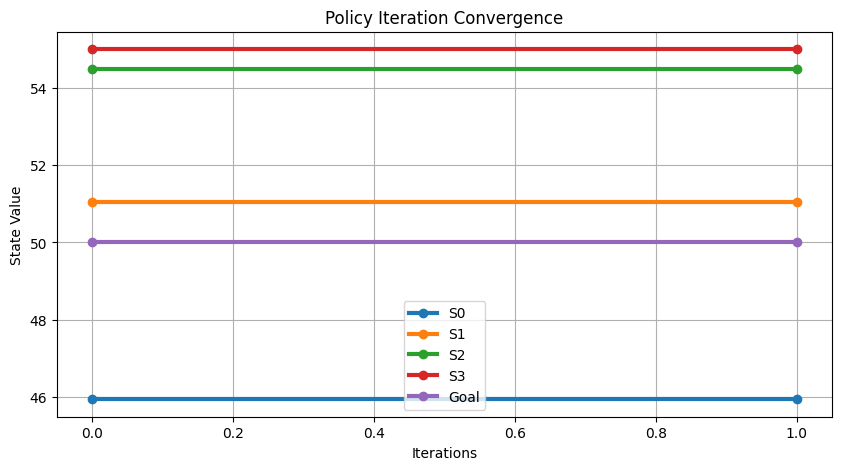

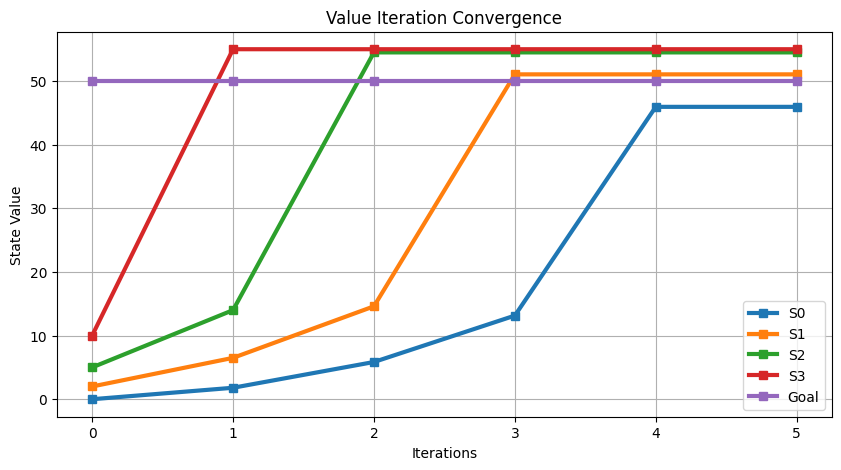

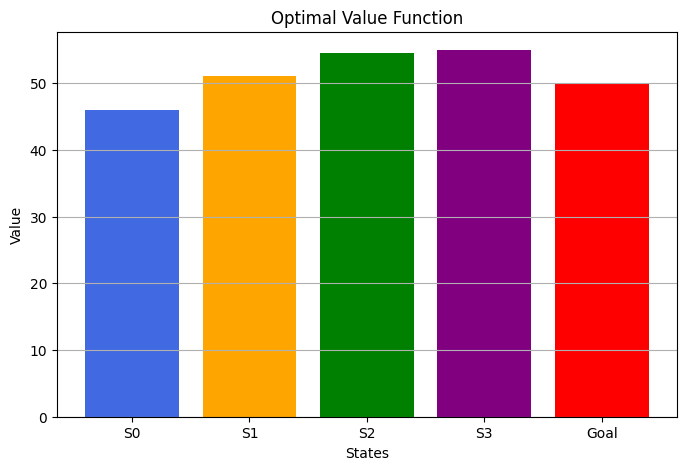

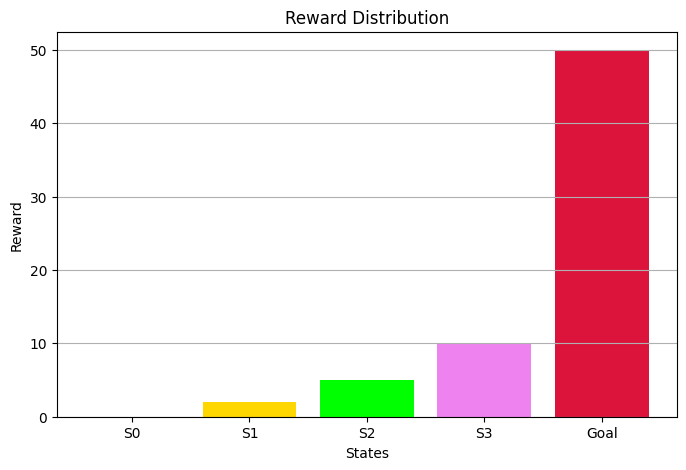

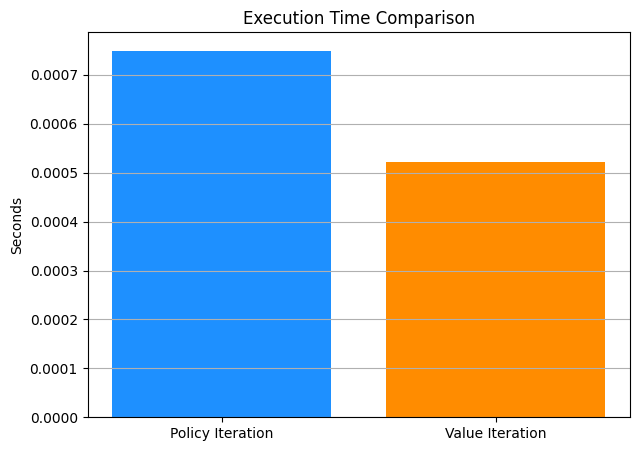

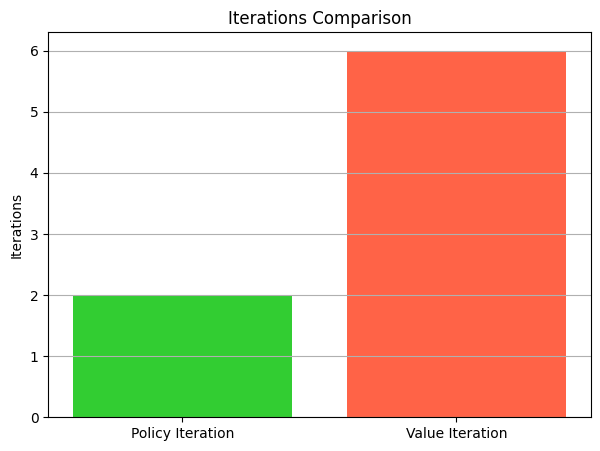

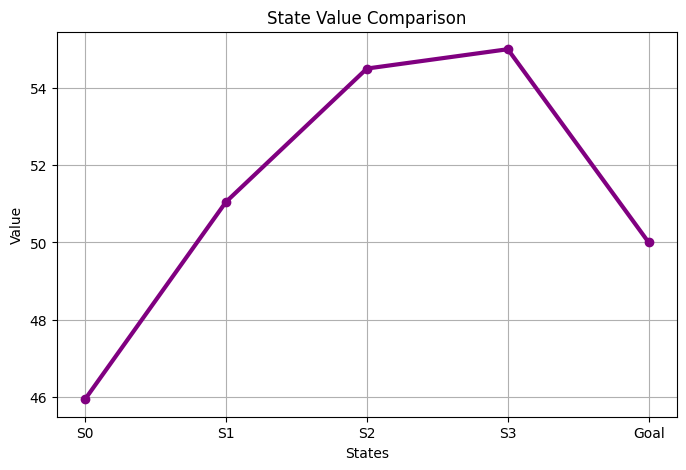

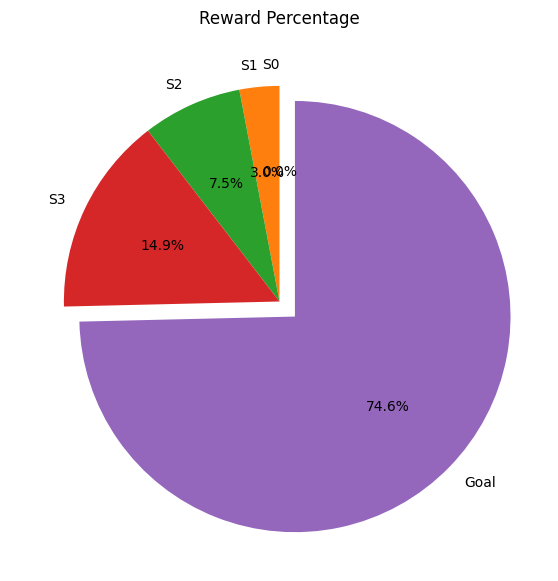

In [ ]:
# ================================================================
# EXPERIMENT 5
# Dynamic Programming using Policy Iteration and Value Iteration
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

print("="*75)
print("EXPERIMENT 5")
print("Dynamic Programming using Policy Iteration and Value Iteration")
print("="*75)

# ================================================================
# AIM
# ================================================================

print("\nAim:")
print("To implement Dynamic Programming using")
print("Policy Iteration and Value Iteration")
print("and compare their performance.")

# ================================================================
# THEORY
# ================================================================

print("\nTheory:")

print("Dynamic Programming solves Markov Decision Processes (MDPs).")

print("Two important algorithms are:")

print("1. Policy Iteration")

print("2. Value Iteration")

# ================================================================
# MDP DEFINITION
# ================================================================

states = ["S0","S1","S2","S3","Goal"]

actions = ["Left","Right"]

n_states = len(states)

n_actions = len(actions)

gamma = 0.90

# Rewards

rewards = np.array([0,2,5,10,50])

# Initial Value Function

V = np.zeros(n_states)

# Random Initial Policy

policy = np.random.randint(0,n_actions,n_states)

policy[-1]=0

print("\nInitial Policy")

for i in range(n_states):

    print(states[i],"->",actions[policy[i]])

# ================================================================
# POLICY ITERATION
# ================================================================

policy_iterations = 0

policy_history = []

policy_values = []

start_policy = time.time()

stable = False

while not stable:

    # ----------------------------
    # POLICY EVALUATION
    # ----------------------------

    for _ in range(20):

        for s in range(n_states-1):

            V[s]=rewards[s]+gamma*V[s+1]

        V[-1]=rewards[-1]

    policy_values.append(V.copy())

    # ----------------------------
    # POLICY IMPROVEMENT
    # ----------------------------

    stable=True

    for s in range(n_states-1):

        old_action=policy[s]

        policy[s]=1

        if old_action!=policy[s]:

            stable=False

    policy_history.append(policy.copy())

    policy_iterations+=1

end_policy=time.time()

policy_time=end_policy-start_policy

print("\nPolicy Iteration Completed")

print("Iterations :",policy_iterations)

print("Execution Time :",round(policy_time,5),"seconds")

# ================================================================
# POLICY RESULTS
# ================================================================

print("\nOptimal Policy")

for i in range(n_states):

    print(states[i],"->",actions[policy[i]])

    # ================================================================
# VALUE ITERATION
# ================================================================

value_function = np.zeros(n_states)

value_history = []

value_iterations = 0

start_value = time.time()

threshold = 0.0001

while True:

    delta = 0

    new_values = value_function.copy()

    for s in range(n_states-1):

        old_value = value_function[s]

        new_values[s] = rewards[s] + gamma * value_function[s+1]

        delta = max(delta, abs(old_value-new_values[s]))

    new_values[-1] = rewards[-1]

    value_function = new_values

    value_history.append(value_function.copy())

    value_iterations += 1

    if delta < threshold:

        break

end_value = time.time()

value_time = end_value-start_value

print("\n")

print("="*70)

print("VALUE ITERATION COMPLETED")

print("="*70)

print("Iterations :",value_iterations)

print("Execution Time :",round(value_time,5),"seconds")


# ================================================================
# OPTIMAL POLICY FROM VALUE ITERATION
# ================================================================

optimal_policy=[]

for s in range(n_states):

    if s==n_states-1:

        optimal_policy.append("Terminal")

    else:

        optimal_policy.append("Move Right")

print("\nOptimal Policy using Value Iteration")

for s,p in zip(states,optimal_policy):

    print(s,"---->",p)


# ================================================================
# FINAL STATE VALUES
# ================================================================

print("\n")

print("="*70)

print("FINAL STATE VALUES")

print("="*70)

for s,v in zip(states,value_function):

    print(s,":",round(v,2))


# ================================================================
# COMPARISON TABLE
# ================================================================

comparison=pd.DataFrame({

"Algorithm":[

"Policy Iteration",

"Value Iteration"

],

"Iterations":[

policy_iterations,

value_iterations

],

"Execution Time":[

round(policy_time,5),

round(value_time,5)

]

})

print("\n")

print("="*70)

print("ALGORITHM COMPARISON")

print("="*70)

print(comparison)

comparison.to_csv("DP_Comparison.csv",index=False)


# ================================================================
# VALUE FUNCTION TABLE
# ================================================================

value_table=pd.DataFrame({

"State":states,

"Reward":rewards,

"Value Function":np.round(value_function,2),

"Optimal Policy":optimal_policy

})

print("\n")

print("="*70)

print("VALUE FUNCTION TABLE")

print("="*70)

print(value_table)

value_table.to_csv("Value_Function.csv",index=False)

# ================================================================
# VISUALIZATION 1
# Policy Iteration Convergence
# ================================================================

policy_values=np.array(policy_values)

plt.figure(figsize=(10,5))

for i in range(n_states):

    plt.plot(policy_values[:,i],
             linewidth=3,
             marker='o',
             label=states[i])

plt.title("Policy Iteration Convergence")

plt.xlabel("Iterations")

plt.ylabel("State Value")

plt.legend()

plt.grid()

plt.show()


# ================================================================
# VISUALIZATION 2
# Value Iteration Convergence
# ================================================================

value_history=np.array(value_history)

plt.figure(figsize=(10,5))

for i in range(n_states):

    plt.plot(value_history[:,i],
             linewidth=3,
             marker='s',
             label=states[i])

plt.title("Value Iteration Convergence")

plt.xlabel("Iterations")

plt.ylabel("State Value")

plt.legend()

plt.grid()

plt.show()


# ================================================================
# VISUALIZATION 3
# Value Function
# ================================================================

plt.figure(figsize=(8,5))

colors=["royalblue","orange","green","purple","red"]

plt.bar(states,
        value_function,
        color=colors)

plt.title("Optimal Value Function")

plt.xlabel("States")

plt.ylabel("Value")

plt.grid(axis='y')

plt.show()


# ================================================================
# VISUALIZATION 4
# Rewards
# ================================================================

plt.figure(figsize=(8,5))

plt.bar(states,
        rewards,
        color=["cyan","gold","lime","violet","crimson"])

plt.title("Reward Distribution")

plt.xlabel("States")

plt.ylabel("Reward")

plt.grid(axis='y')

plt.show()


# ================================================================
# VISUALIZATION 5
# Execution Time Comparison
# ================================================================

plt.figure(figsize=(7,5))

plt.bar(

["Policy Iteration",
 "Value Iteration"],

[policy_time,
 value_time],

color=["dodgerblue",
       "darkorange"]

)

plt.title("Execution Time Comparison")

plt.ylabel("Seconds")

plt.grid(axis='y')

plt.show()


# ================================================================
# VISUALIZATION 6
# Iteration Comparison
# ================================================================

plt.figure(figsize=(7,5))

plt.bar(

["Policy Iteration",
 "Value Iteration"],

[policy_iterations,
 value_iterations],

color=["limegreen",
       "tomato"]

)

plt.title("Iterations Comparison")

plt.ylabel("Iterations")

plt.grid(axis='y')

plt.show()


# ================================================================
# VISUALIZATION 7
# State Value Comparison
# ================================================================

plt.figure(figsize=(8,5))

plt.plot(states,
         value_function,
         marker='o',
         linewidth=3,
         color="purple")

plt.title("State Value Comparison")

plt.xlabel("States")

plt.ylabel("Value")

plt.grid()

plt.show()


# ================================================================
# VISUALIZATION 8
# Reward Percentage
# ================================================================

plt.figure(figsize=(7,7))

plt.pie(rewards,
        labels=states,
        autopct="%1.1f%%",
        startangle=90,
        explode=[0,0,0,0,0.1])

plt.title("Reward Percentage")

plt.show()